In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Đọc tệp CSV
file_path = 'orders_with_1_items.csv'  # Thay bằng tệp của bạn
data = pd.read_csv(file_path)

# Kiểm tra cột 'items in order'
if 'Items in order' in data.columns:
    # Tiền xử lý dữ liệu
    data['Items in order'] = data['Items in order'].str.lower().str.replace('[^a-zA-Z0-9, ]', '', regex=True)
    
    # Vector hóa dữ liệu
    vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(','))
    item_vectors = vectorizer.fit_transform(data['Items in order'])
    
    # Phân cụm bằng K-Means
    num_clusters =  3 # Số cụm mong muốn
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    data['cluster'] = kmeans.fit_predict(item_vectors)
    
    # Lưu kết quả
    print(data[['Items in order', 'cluster']])
    data.to_csv('clustered_orders_1.csv', index=False)
else:
    print("Cột 'items in order' không tồn tại trong tệp.")

                                   Items in order  cluster
0           1 x bone in peri peri grilled chicken        0
1              1 x bone in angara grilled chicken        0
2            1 x grilled chicken peri peri tangdi        0
3            1 x bone in jamaican grilled chicken        0
4            1 x bone in jamaican grilled chicken        0
...                                           ...      ...
7537   1 x angara boneless grilled chicken breast        0
7538       1 x fried chicken boneless bites  6pcs        0
7539  1 x fried chicken desi peri peri bites bone        0
7540                          1 x ooh saucy fries        0
7541          1 x grilled chicken jamaican slider        0

[7542 rows x 2 columns]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Số lượng order trong mỗi cụm:
cluster
0    6897
2     413
1     232
Name: count, dtype: int64

Cụm 0:
Số lượng order: 6897
Các món phổ biến nhất:
1 x bageecha pizza                      801
1 x bone in jamaican grilled chicken    527
1 x margherita pizza                    368
1 x chilli cheese garlic bread          312
1 x makhani paneer pizza                310
Name: count, dtype: int64

Cụm 1:
Số lượng order: 232
Các món phổ biến nhất:
1 x tripple cheese pizza    232
Name: count, dtype: int64

Cụm 2:
Số lượng order: 413
Các món phổ biến nhất:
1 x all about chicken pizza    413
Name: count, dtype: int64


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


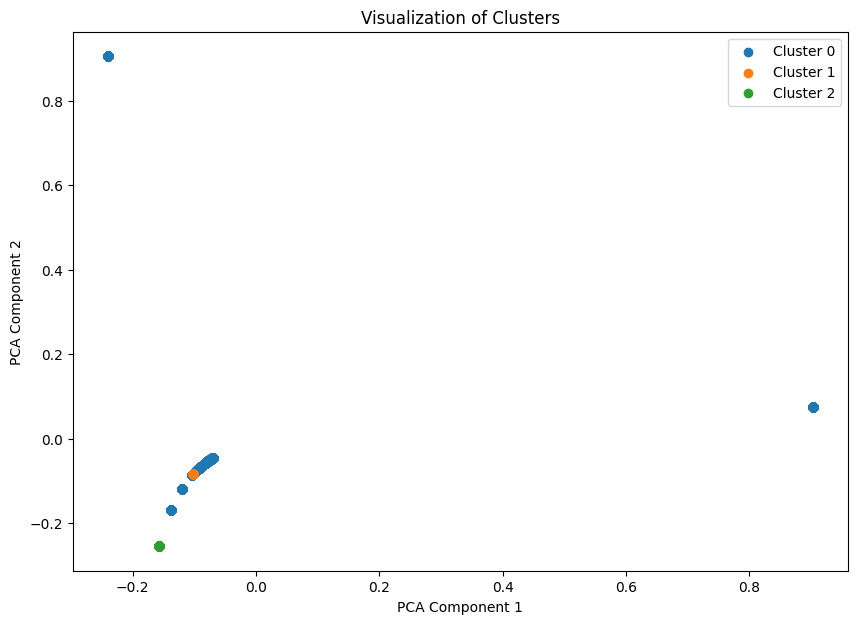

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Đọc tệp CSV
file_path = 'orders_with_1_items.csv'  # Thay bằng tệp của bạn
data = pd.read_csv(file_path)

# Kiểm tra cột 'items in order'
if 'Items in order' in data.columns:
    # Tiền xử lý dữ liệu
    data['Items in order'] = data['Items in order'].str.lower().str.replace('[^a-zA-Z0-9, ]', '', regex=True)
    
    # Vector hóa dữ liệu
    vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(','))
    item_vectors = vectorizer.fit_transform(data['Items in order'])
    
    # Phân cụm bằng K-Means
    num_clusters = 3  # Số cụm mong muốn
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    data['cluster'] = kmeans.fit_predict(item_vectors)
    
    # Đếm số lượng order trong mỗi cụm
    cluster_counts = data['cluster'].value_counts()
    print("Số lượng order trong mỗi cụm:")
    print(cluster_counts)
    
    # Xác định đặc trưng của mỗi cụm
    for cluster in range(num_clusters):
        cluster_data = data[data['cluster'] == cluster]
        all_items = ','.join(cluster_data['Items in order']).split(',')
        item_counts = pd.Series(all_items).value_counts()
        print(f"\nCụm {cluster}:")
        print(f"Số lượng order: {len(cluster_data)}")
        print("Các món phổ biến nhất:")
        print(item_counts.head(5))  # Hiển thị 5 món phổ biến nhất
    
    # Giảm chiều dữ liệu bằng PCA
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(item_vectors.toarray())
    
    # Vẽ biểu đồ phân cụm
    plt.figure(figsize=(10, 7))
    for cluster in range(num_clusters):
        cluster_points = reduced_data[data['cluster'] == cluster]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}')
    
    plt.title('Visualization of Clusters')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend()
    plt.show()
else:
    print("Cột 'items in order' không tồn tại trong tệp.")